In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb

In [2]:
df=pd.read_excel("../Data_set/Credir_Card_Bank.xlsx")
df

,Customer_ID,Age,Gender,Employment_Type,Occupation,Monthly_Income,Annual_Income,Credit_Score,Years_With_Bank,Existing_Credit_Cards,...,Credit_Utilization,Credit_History_Years,Missed_Payments,Late_Payment_Count,Number_of_Defaults,Residential_Status,PAN_Verified,KYC_Status,Fraud_Flag,Credit_Limit
0,CUST00001,41,Female,Salaried,Sales Executive,140273,1683276,811,4,4,...,34,11,0,8,0,Rent,Yes,Complete,No,1373925
1,CUST00002,23,Male,Self-Employed,Business Owner,209521,2514252,837,12,2,...,71,20,3,3,0,Own,Yes,Complete,No,1902449
2,CUST00003,45,Female,Salaried,Designer,47682,572184,679,2,6,...,88,12,5,2,0,Rent,Yes,Complete,No,1165913
3,CUST00004,39,Male,Salaried,Doctor,214966,2579592,660,5,0,...,66,4,3,5,0,Rent,Yes,Complete,No,1869491
4,CUST00005,58,Male,Self-Employed,Designer,30051,360612,589,18,0,...,70,1,4,2,0,Own,Yes,Complete,No,825275
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,CUST04996,48,Male,Salaried,Doctor,55078,660936,824,12,1,...,91,7,4,4,0,Rent,Yes,Complete,No,1156917
4996,CUST04997,59,Female,Self-Employed,Accountant,107040,1284480,840,0,1,...,28,22,1,6,0,Own,Yes,Complete,No,1458578
4997,CUST04998,26,Female,Salaried,Doctor,168754,2025048,632,19,0,...,38,11,3,1,0,Rent,Yes,Complete,No,1342610
4998,CUST04999,42,Male,Salaried,Manager,197110,2365320,734,9,2,...,15,3,2,2,0,Own,Yes,Complete,No,1868828


**Analyze Customers with Defaults**

In [3]:
default_customers = df[df["Number_of_Defaults"]>0]

print("Total Customers :",len(df))
print("Customers with Default :",len(default_customers))

Total Customers : 5000
Customers with Default : 319


C:\Users\ASUS\AppData\Local\Temp\ipykernel_17864\2945855795.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sb.countplot(


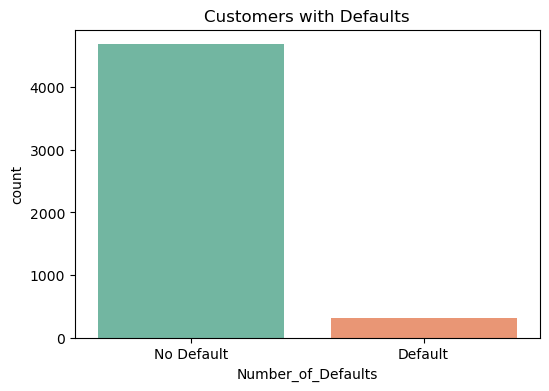

In [4]:
plt.figure(figsize=(6,4))

sb.countplot(
    x=df["Number_of_Defaults"]>0,
    palette="Set2"
)

plt.xticks([0,1],["No Default","Default"])

plt.title("Customers with Defaults")

plt.show()

**Analyze Missed Payments**

In [5]:
df["Missed_Payments"].describe()

count    5000.000000
mean        2.454800
std         1.702274
min         0.000000
25%         1.000000
50%         2.000000
75%         4.000000
max         5.000000
Name: Missed_Payments, dtype: float64

In [6]:
print(df["Missed_Payments"].mean())

2.4548


In [7]:
top_missed=df.sort_values("Missed_Payments",ascending=False)

top_missed.head(10)

,Customer_ID,Age,Gender,Employment_Type,Occupation,Monthly_Income,Annual_Income,Credit_Score,Years_With_Bank,Existing_Credit_Cards,...,Credit_Utilization,Credit_History_Years,Missed_Payments,Late_Payment_Count,Number_of_Defaults,Residential_Status,PAN_Verified,KYC_Status,Fraud_Flag,Credit_Limit
16,CUST00017,57,Female,Self-Employed,Designer,175588,2107056,635,12,1,...,87,20,5,6,0,Rent,Yes,Complete,No,1547693
2422,CUST02423,60,Male,Salaried,Accountant,224660,2695920,602,1,1,...,78,10,5,5,0,Rent,Yes,Complete,No,1729875
2426,CUST02427,30,Male,Self-Employed,Software Engineer,219255,2631060,790,19,2,...,45,15,5,8,0,Own,Yes,Complete,No,1733728
2427,CUST02428,50,Female,Self-Employed,Sales Executive,229876,2758512,607,2,4,...,21,20,5,8,0,Rent,Yes,Complete,No,1693278
2454,CUST02455,41,Male,Self-Employed,Sales Executive,229168,2750016,726,1,3,...,22,16,5,2,0,Own,Yes,Complete,No,1986430
2459,CUST02460,47,Female,Self-Employed,Teacher,218596,2623152,727,8,0,...,31,4,5,3,0,Rent,Yes,Complete,No,1657825
2466,CUST02467,22,Female,Self-Employed,Manager,60700,728400,631,5,5,...,80,6,5,2,0,Own,Yes,Complete,No,944292
48,CUST00049,36,Male,Salaried,Business Owner,194732,2336784,787,4,0,...,39,24,5,0,0,Rent,Yes,Complete,No,1794858
4961,CUST04962,34,Female,Self-Employed,Sales Executive,66053,792636,588,11,5,...,25,9,5,7,1,Rent,Yes,Complete,No,792826
4962,CUST04963,51,Female,Self-Employed,Software Engineer,182724,2192688,819,14,0,...,30,22,5,3,0,Rent,Yes,Complete,No,1683103


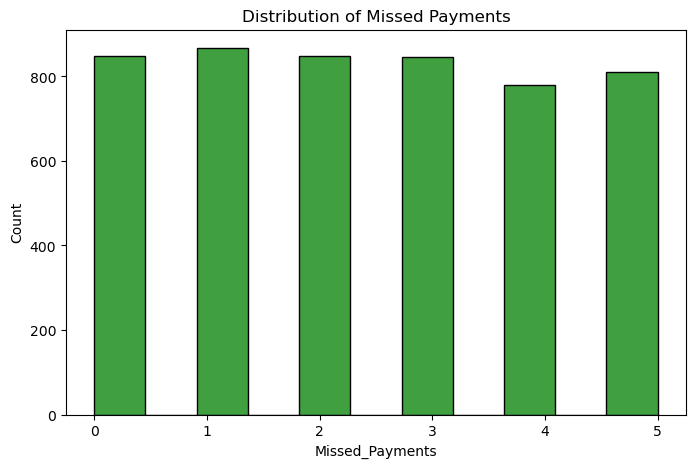

In [8]:
plt.figure(figsize=(8,5))

sb.histplot(df["Missed_Payments"],bins=11,color="green")

plt.title("Distribution of Missed Payments")

plt.show()

**Analyze Late Payment Trends**

In [9]:
df["Late_Payment_Count"].describe()

count    5000.000000
mean        3.940800
std         2.577329
min         0.000000
25%         2.000000
50%         4.000000
75%         6.000000
max         8.000000
Name: Late_Payment_Count, dtype: float64

In [10]:
print(df["Late_Payment_Count"].mean())

3.9408


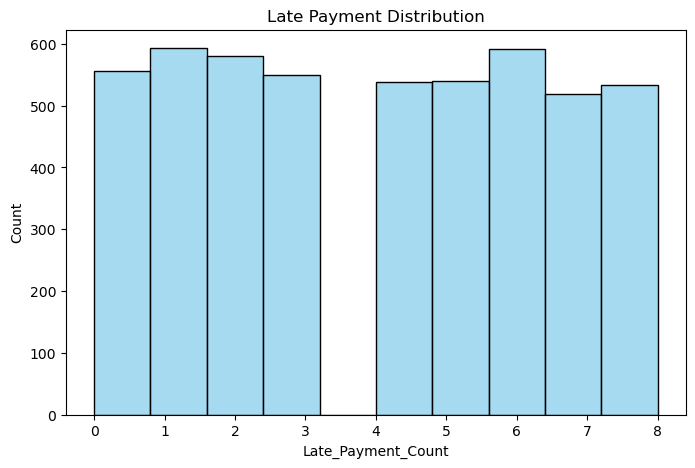

In [11]:
plt.figure(figsize=(8,5))

sb.histplot(df["Late_Payment_Count"],bins=10,color="skyblue")

plt.title("Late Payment Distribution")

plt.show()

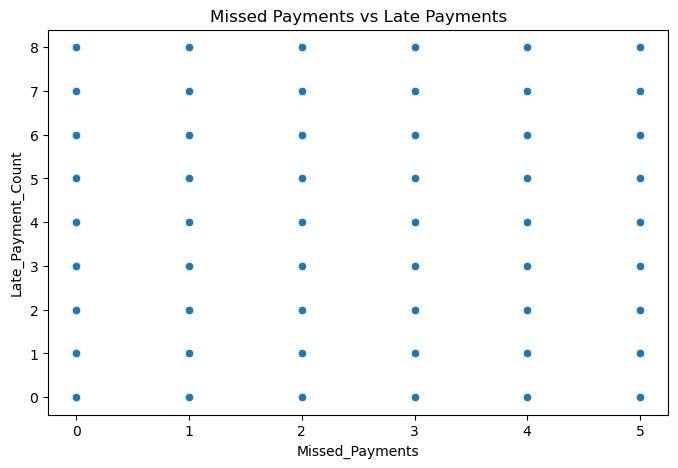

In [12]:
plt.figure(figsize=(8,5))

sb.scatterplot(data=df,
                x="Missed_Payments",
                y="Late_Payment_Count")

plt.title("Missed Payments vs Late Payments")

plt.show()

**Identify High-Risk Customer Groups**

In [13]:
df["Risk_Score"]=(
    df["Number_of_Defaults"]*4+
    df["Missed_Payments"]*2+
    df["Late_Payment_Count"]+
    (100-df["Credit_Score"])/10
)

In [14]:
conditions=[
    df["Risk_Score"]<10,
    (df["Risk_Score"]>=10)&(df["Risk_Score"]<20),
    df["Risk_Score"]>=20
]

choices=["Low Risk","Medium Risk","High Risk"]

df["Risk_Category"]=np.select(conditions,choices,default="Low Risk")

In [15]:
df["Risk_Category"].value_counts()

Risk_Category
Low Risk    5000
Name: count, dtype: int64

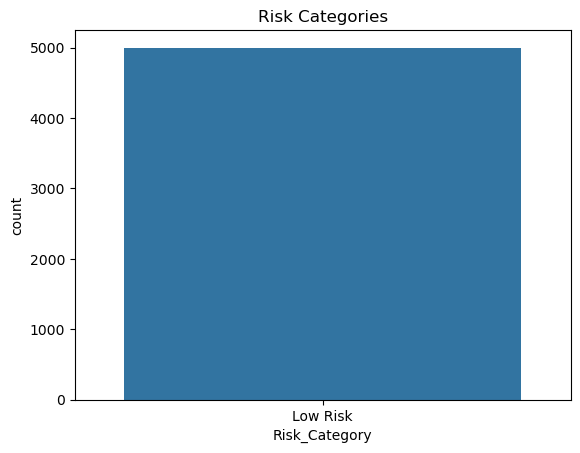

In [16]:
sb.countplot(data=df,x="Risk_Category")

plt.title("Risk Categories")

plt.show()

**Compare Risk Across Occupations**

In [17]:
occupation_risk=df.groupby("Occupation")["Risk_Score"].mean().sort_values(ascending=False)

occupation_risk

Occupation
Sales Executive     -50.794277
Business Owner      -50.815331
Designer            -50.927035
Doctor              -51.027229
Teacher             -51.209866
Accountant          -51.211682
Manager             -51.219699
Software Engineer   -51.478626
Name: Risk_Score, dtype: float64

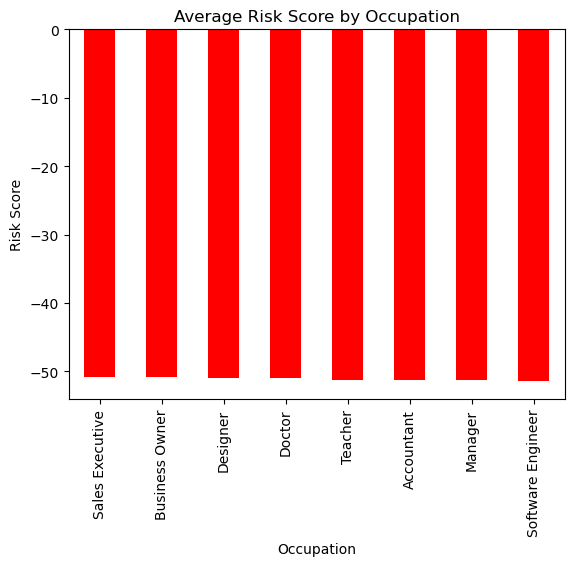

In [18]:
occupation_risk.plot(kind="bar",color="red")

plt.title("Average Risk Score by Occupation")

plt.ylabel("Risk Score")

plt.xticks(rotation=90)

plt.show()

**Compare Risk Across Age Groups**

In [19]:
bins=[20,30,40,50,60]

labels=["21-30","31-40","41-50","51-60"]

df["Age_Group"]=pd.cut(df["Age"],bins=bins,labels=labels)

In [20]:
age_risk=df.groupby("Age_Group")["Risk_Score"].mean()

age_risk

C:\Users\ASUS\AppData\Local\Temp\ipykernel_17864\3479101302.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_risk=df.groupby("Age_Group")["Risk_Score"].mean()


Age_Group
21-30   -51.350712
31-40   -51.059184
41-50   -50.826224
51-60   -51.110361
Name: Risk_Score, dtype: float64

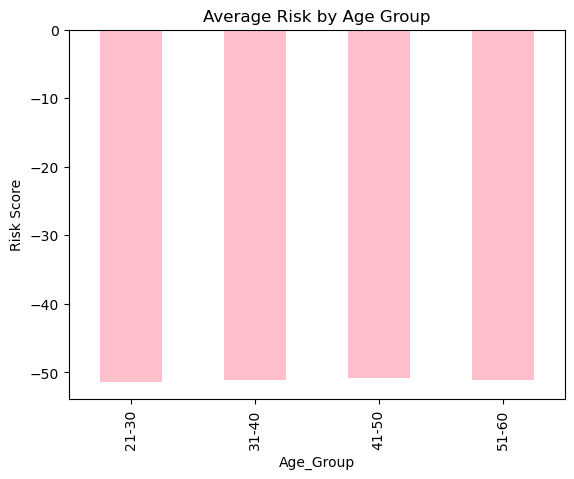

In [21]:
age_risk.plot(kind="bar",color="pink")

plt.title("Average Risk by Age Group")

plt.ylabel("Risk Score")

plt.show()